IMDb India Movies - EDA
========================================
Author  : SOUMI MUKHERJEE | Data Analyst
Dataset : IMDb_Movies_India.csv
 
Columns in dataset:
    Name, Year, Duration, Genre, Rating, Votes, Director, Actor 1, Actor 2, Actor 3



In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
 
warnings.filterwarnings("ignore")

In [223]:
df = pd.read_csv("D:/CODSOFT/TASK 2/IMDb Movies India.csv", encoding="latin1")
 
print("=" * 55)
print("STEP 1 — Raw Data Overview")
print("=" * 55)
print(f"Shape (rows × columns): {df.shape}")
print("\nColumn Data Types:")
print(df.dtypes)
print("\nFirst 3 rows:")
print(df.head(3))

STEP 1 — Raw Data Overview
Shape (rows × columns): (15509, 10)

Column Data Types:
Name         object
Year         object
Duration     object
Genre        object
Rating      float64
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

First 3 rows:
                                 Name    Year Duration           Genre  \
0                                         NaN      NaN           Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min           Drama   
2                         #Homecoming  (2021)   90 min  Drama, Musical   

   Rating Votes            Director       Actor 1            Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji             Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal     Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta  Plabita Borthakur   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  


In [224]:
print("\n" + "=" * 55)
print("STEP 2 — Missing Value Summary")
print("=" * 55)
 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0])


STEP 2 — Missing Value Summary
          Missing Count  Missing %
Year                528       3.40
Duration           8269      53.32
Genre              1877      12.10
Rating             7590      48.94
Votes              7589      48.93
Director            525       3.39
Actor 1            1617      10.43
Actor 2            2384      15.37
Actor 3            3144      20.27


In [225]:
print("\n" + "=" * 55)
print("STEP 3 — Remove Duplicates")
print("=" * 55)
 
before = len(df)
df.drop_duplicates(subset=['Name'], keep='last', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows before: {before}  |  Rows after: {len(df)}  |  Removed: {before - len(df)}")


STEP 3 — Remove Duplicates
Rows before: 15509  |  Rows after: 13838  |  Removed: 1671


In [226]:
print("\n" + "=" * 55)
print("STEP 4 — Clean 'Name' Column")
print("=" * 55)
 
# Strip leading/trailing whitespace
df["Name"] = df["Name"].str.strip()
 
# Drop rows where Name is empty / whitespace only (unusable records)
blank_names = df["Name"].replace("", np.nan).isnull().sum()
df = df[df["Name"].replace("", np.nan).notna()].reset_index(drop=True)
print(f"Blank/empty Name rows removed: {blank_names}")


STEP 4 — Clean 'Name' Column
Blank/empty Name rows removed: 1


In [227]:
print("\n" + "=" * 55)
print("STEP 5 — Clean 'Year' Column  (e.g. '(2019)' → 2019)")
print("=" * 55)
 
# Remove parentheses and extract the 4-digit year
df["Year"] = df["Year"].str.extract(r"(\d{4})")   # keeps only digits
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")  # cast to float/int
df['Year'].replace("", np.nan, inplace=True)
 
# Sanity check: drop rows with years that look unrealistic
valid_year_mask = df["Year"].between(1900, 2025)
print(f"Rows with invalid/missing Year: {(~valid_year_mask).sum()}")
# Keep NaN rows (missing years) but flag unrealistic ones
df.loc[~valid_year_mask & df["Year"].notna(), "Year"] = np.nan
 
df["Year"] = df["Year"].astype("Int64")  # nullable integer
print(f"Missing Year values: {df['Year'].isna().sum()}")
print(f"Year range: {df['Year'].min()} – {df['Year'].max()}")


STEP 5 — Clean 'Year' Column  (e.g. '(2019)' → 2019)
Rows with invalid/missing Year: 517
Missing Year values: 517
Year range: 1913 – 2022


In [228]:
print("\n" + "=" * 55)
print("STEP 6 — Clean 'Duration' Column  (e.g. '109 min' → 109)")
print("=" * 55)
 
df["Duration"] = df["Duration"].str.extract(r"(\d+)")
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce").astype("Int64")
 
print(f"Missing Duration values: {df['Duration'].isna().sum()}")
print(f"Duration range: {df['Duration'].min()} – {df['Duration'].max()} minutes")


STEP 6 — Clean 'Duration' Column  (e.g. '109 min' → 109)
Missing Duration values: 7365
Duration range: 2 – 321 minutes


In [229]:
print("\n" + "=" * 55)
print("STEP 7 — Clean 'Votes' Column  (e.g. '1,086' → 1086)")
print("=" * 55)
 
df["Votes"] = df["Votes"].astype(str).str.replace(",", "", regex=False)
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce").astype("Int64")
 
print(f"Missing Votes values: {df['Votes'].isna().sum()}")


STEP 7 — Clean 'Votes' Column  (e.g. '1,086' → 1086)
Missing Votes values: 6897


In [230]:
print("\n" + "=" * 55)
print("STEP 8 — Validate 'Rating' Column (should be 1–10)")
print("=" * 55)
 
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
 
# Flag ratings outside valid IMDb range
out_of_range = df["Rating"].notna() & ~df["Rating"].between(1, 10)
print(f"Ratings outside 1–10 range: {out_of_range.sum()}")
df.loc[out_of_range, "Rating"] = np.nan
print(f"Missing Rating values: {df['Rating'].isna().sum()}")


STEP 8 — Validate 'Rating' Column (should be 1–10)
Ratings outside 1–10 range: 0
Missing Rating values: 6897


In [231]:
print("\n" + "=" * 55)
print("STEP 9 — Strip Whitespace from Text Columns")
print("=" * 55)
 
text_cols = ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]
for col in text_cols:
    df[col] = df[col].str.strip()
    # Standardise: replace empty strings with NaN
    df[col] = df[col].replace("", np.nan)
 
print("Done — all text columns stripped and empty strings → NaN")


STEP 9 — Strip Whitespace from Text Columns
Done — all text columns stripped and empty strings → NaN


In [232]:
print("\n" + "=" * 55)
print("STEP 10 — Missing Value Strategy")
print("=" * 55)
 
# Rating & Votes: leave as NaN — do NOT impute, they are factual fields
# Genre: fill unknown with 'Unknown'
df["Genre"] = df["Genre"].fillna("Unknown")
 
# Duration: fill with median (reasonable central estimate for numeric EDA)
median_duration = df["Duration"].median()
df["Duration"] = df["Duration"].fillna(median_duration).astype("Int64")

# Director, Actor1,2,3: fill with "Unknown"
df['Director'] = df['Director'].fillna("Unknown")
df['Actor 1'] = df['Actor 1'].fillna("Unknown")
df['Actor 2'] = df['Actor 2'].fillna("Unknown")
df['Actor 3'] = df['Actor 3'].fillna("Unknown")
 
# Year, Director, Actor columns: leave as NaN — imputing names is risky
print("Genre NaN  → filled with 'Unknown'")
print(f"Duration NaN → filled with median ({median_duration} min)")
print("Rating, Votes, Year, Director, Actors → kept as NaN (no imputation)")


STEP 10 — Missing Value Strategy
Genre NaN  → filled with 'Unknown'
Duration NaN → filled with median (129.0 min)
Rating, Votes, Year, Director, Actors → kept as NaN (no imputation)


In [233]:
# Dropping the missing values of Rating column from the dataset 
df = df.dropna(subset=["Rating"])

In [234]:
print("\n" + "=" * 55)
print("STEP 11 — Add Derived Columns for EDA")
print("=" * 55)
 
# Decade column — useful for trend analysis
df["Decade"] = (df["Year"] // 10 * 10).astype("Int64")
 
# Primary Genre (first genre listed before any comma)
df["Primary_Genre"] = df["Genre"].str.split(",").str[0].str.strip()
 
# Rating band — useful for grouping in charts
bins   = [0, 4, 6, 8, 10]
labels = ["Poor (<4)", "Average (4–6)", "Good (6–8)", "Excellent (8–10)"]
df["Rating_Band"] = pd.cut(df["Rating"], bins=bins, labels=labels)
 
print("New columns added:")
print("  • Decade        — rounded-down year (e.g. 2019 → 2010)")
print("  • Primary_Genre — first genre token (e.g. 'Drama, Comedy' → 'Drama')")
print("  • Rating_Band   — categorical rating bucket")


STEP 11 — Add Derived Columns for EDA
New columns added:
  • Decade        — rounded-down year (e.g. 2019 → 2010)
  • Primary_Genre — first genre token (e.g. 'Drama, Comedy' → 'Drama')
  • Rating_Band   — categorical rating bucket


In [235]:
print("\n" + "=" * 55)
print("STEP 12 — Final Cleaned Data Summary")
print("=" * 55)
 
print(f"Final Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nRemaining Missing Values:")
print(df.isnull().sum())
print("\nSample cleaned rows:")
print(df.head(5).to_string())


STEP 12 — Final Cleaned Data Summary
Final Shape: (6940, 13)

Data Types:
Name               object
Year                Int64
Duration            Int64
Genre              object
Rating            float64
Votes               Int64
Director           object
Actor 1            object
Actor 2            object
Actor 3            object
Decade              Int64
Primary_Genre      object
Rating_Band      category
dtype: object

Remaining Missing Values:
Name             0
Year             0
Duration         0
Genre            0
Rating           0
Votes            0
Director         0
Actor 1          0
Actor 2          0
Actor 3          0
Decade           0
Primary_Genre    0
Rating_Band      0
dtype: int64

Sample cleaned rows:
                                 Name  Year  Duration                      Genre  Rating  Votes        Director          Actor 1                 Actor 2          Actor 3  Decade Primary_Genre    Rating_Band
0  #Gadhvi (He thought he was Gandhi)  2019       109    

### For viewing the unique values 

In [236]:
# Function to display unique values from a given column
def show_unique_values(df, column_name):
    try:
        if column_name not in df.columns:
            raise ValueError(f"Column '{column_name}' does not exist in DataFrame.")
        
        unique_vals = df[column_name].unique()  # Get unique values
        print(f"Unique values in column '{column_name}':")
        for val in unique_vals:
            print(val)
    except Exception as e:
        print(f"Error: {e}")

show_unique_values(df, 'Genre')

Unique values in column 'Genre':
Drama
Comedy, Romance
Comedy, Drama, Musical
Drama, Romance, War
Horror, Mystery, Thriller
Action, Crime, Thriller
Horror
Horror, Romance, Thriller
Comedy, Drama, Romance
Comedy, Drama
Horror, Thriller
Comedy, Horror
Drama, Horror, Mystery
Action, Thriller
Action
Drama, History
Horror, Mystery, Romance
Horror, Mystery
Drama, Horror, Romance
Action, Drama, History
Action, Drama, War
Thriller
Comedy
Comedy, Family
Adventure, Horror, Mystery
Action, Sci-Fi
Crime, Mystery, Thriller
Sport
Biography, Drama, History
Unknown
Horror, Romance
Crime, Drama
Drama, Romance
Adventure, Drama
Comedy, Mystery, Thriller
Action, Crime, Drama
Crime, Thriller
Horror, Sci-Fi, Thriller
Drama, Mystery, Thriller
Drama, Sport
Drama, Family, Musical
Comedy, Thriller
Action, Adventure, Fantasy
Action, Drama
Documentary
Drama, Horror, Musical
Action, Biography, Drama
Action, Fantasy, Mystery
Adventure, Drama, Mystery
Mystery, Thriller
Comedy, Crime, Drama
Musical, Romance
Drama, Th

In [17]:
output_path = "IMDb_India_Cleaned.csv"
df.to_csv(output_path, index=False)
print(f"\n✅ Cleaned data saved to: {output_path}")
print("   You can now use this file for EDA (charts, correlations, group-bys, etc.)")


✅ Cleaned data saved to: IMDb_India_Cleaned.csv
   You can now use this file for EDA (charts, correlations, group-bys, etc.)


### FEATURE ENGINEERING

In [237]:
# Log-transform Votes 
df["Votes_log"] = np.log1p(df["Votes"])

In [238]:
# Label-encode Primary_Genre
le_genre = LabelEncoder()
df["Genre_encoded"] = le_genre.fit_transform(df["Primary_Genre"])

In [239]:
# Frequency-encode Director & Actors
def frequency_encode(series):
    """Replace each category with its proportion in the dataset."""
    freq = series.value_counts(normalize=True)
    return series.map(freq)
 
df["Director_freq"] = frequency_encode(df["Director"])
df["Actor1_freq"]   = frequency_encode(df["Actor 1"])
df["Actor2_freq"]   = frequency_encode(df["Actor 2"])
df["Actor3_freq"]   = frequency_encode(df["Actor 3"])

In [240]:
# Derived: Is the director in the top 10% by appearances?
top_dir_threshold   = df["Director_freq"].quantile(0.90)
df["Director_popular"] = (df["Director_freq"] >= top_dir_threshold).astype(int)

In [241]:
# Movie age
df["Movie_Age"] = 2024 - df["Year"]

### OUTLIERS HANDLING

In [242]:
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['Rating'] < lower_bound) | (df['Rating'] > upper_bound)]
df = df[(df['Rating'] >= lower_bound) & (df['Rating'] <= upper_bound)]
print(len(outliers))

11


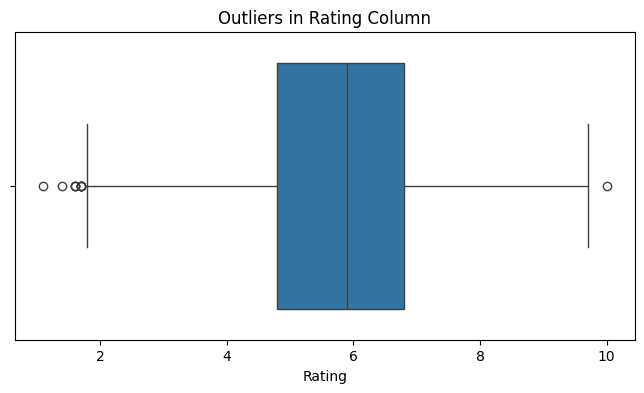

In [183]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Rating'])
plt.title('Outliers in Rating Column')
plt.show()

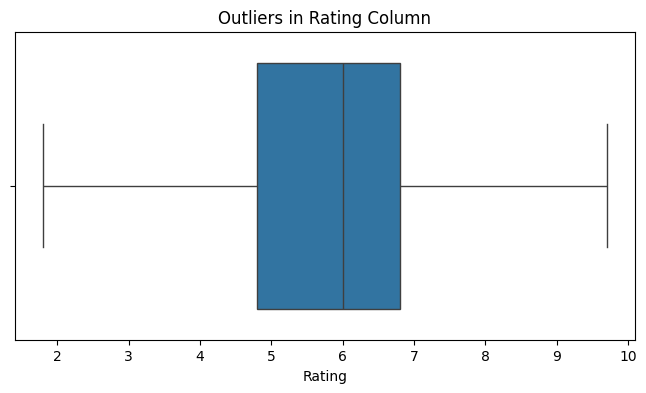

In [243]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Rating'])
plt.title('Outliers in Rating Column')
plt.show()

### REGRESSION ANALYSIS

In [244]:
X = df.drop(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 
             'Actor 1', 'Actor 2', 'Actor 3', 'Decade', 'Primary_Genre', 
             'Rating_Band'], axis=1) 

y = df['Rating']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [245]:
# This automatically selects only float and integer columns
X = df.select_dtypes(include=['float64', 'int64'])

# Make sure to remove the 'Rating' from X if it's still there!
if 'Rating' in X.columns:
    X = X.drop('Rating', axis=1)

In [246]:
# 4. Build and Fit the Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Evaluate
y_pred = model.predict(X_test_scaled)
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")

R^2 Score: 0.1134


### Random Forest Classifier

In [247]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the Random Forest Regressor
# n_estimators=100 means we are using 100 individual decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Fit the model using your scaled training data
rf_model.fit(X_train_scaled, y_train)

# 3. Make predictions
rf_pred = rf_model.predict(X_test_scaled)

# 4. Evaluate the performance
print(f"Random Forest R^2 Score: {r2_score(y_test, rf_pred):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_pred):.4f}")

Random Forest R^2 Score: 0.2991
Random Forest MAE: 0.8876


In [248]:
print(f"Model expected {len(rf_model.feature_importances_)} features.")
print(f"Your 'X' has {len(X.columns)} features.")
print(f"Your 'X_train' has {len(X_train.columns)} features.")

Model expected 8 features.
Your 'X' has 12 features.
Your 'X_train' has 8 features.


### PLOTTING

In [249]:
# 1. Get feature names and importance scores
# We use X_train.columns to ensure the lengths match perfectly
importances = rf_model.feature_importances_
feature_names = X_train.columns 

# 2. Create the DataFrame
# This will now have the same length for both 'Feature' and 'Importance'
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

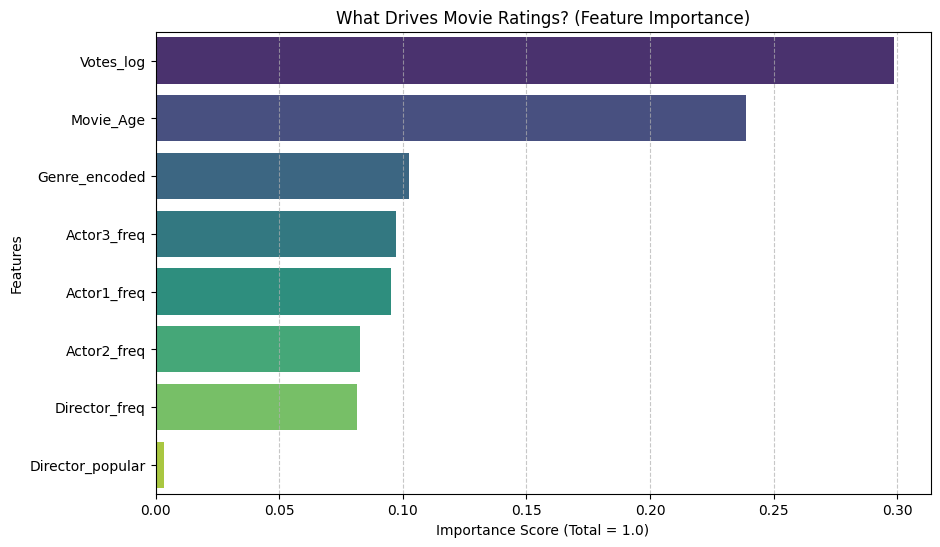

In [202]:
# 3. Plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('What Drives Movie Ratings? (Feature Importance)')
plt.xlabel('Importance Score (Total = 1.0)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Colour Palatte

In [250]:
BG      = "#0d0f18"
CARD    = "#13162b"
BORDER  = "#1e2140"
PURPLE  = "#7c3aed"
AMBER   = "#f59e0b"
GREEN   = "#10b981"
RED     = "#ef4444"
BLUE    = "#3b82f6"
PINK    = "#ec4899"
TEXT    = "#13162b"
SUBTEXT = "#94a3b8"
PALETTE = [PURPLE, AMBER, GREEN, RED, BLUE, PINK]

### VISUALISATIONS

### Rating Distribution

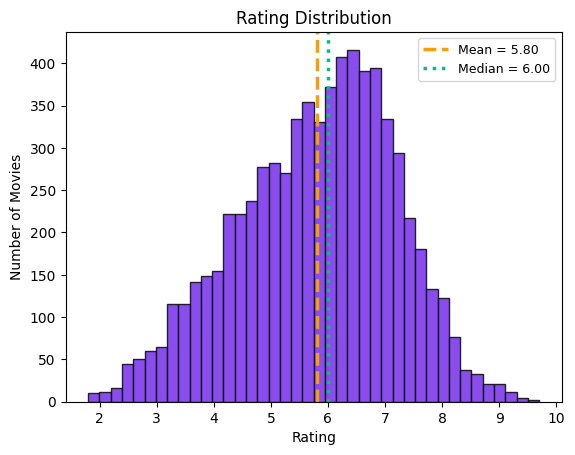

In [251]:
plt.hist(df["Rating"], bins=40, color=PURPLE, edgecolor=BG, alpha=0.9)

# Add mean line
plt.axvline(df["Rating"].mean(), color=AMBER, lw=2.5, ls="--",
            label=f"Mean = {df['Rating'].mean():.2f}")

# Add median line
plt.axvline(df["Rating"].median(), color=GREEN, lw=2.5, ls=":",
            label=f"Median = {df['Rating'].median():.2f}")

# Legend
plt.legend(fontsize=9)

# Labels and title
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()

### Genre vs. Rating (Distribution)

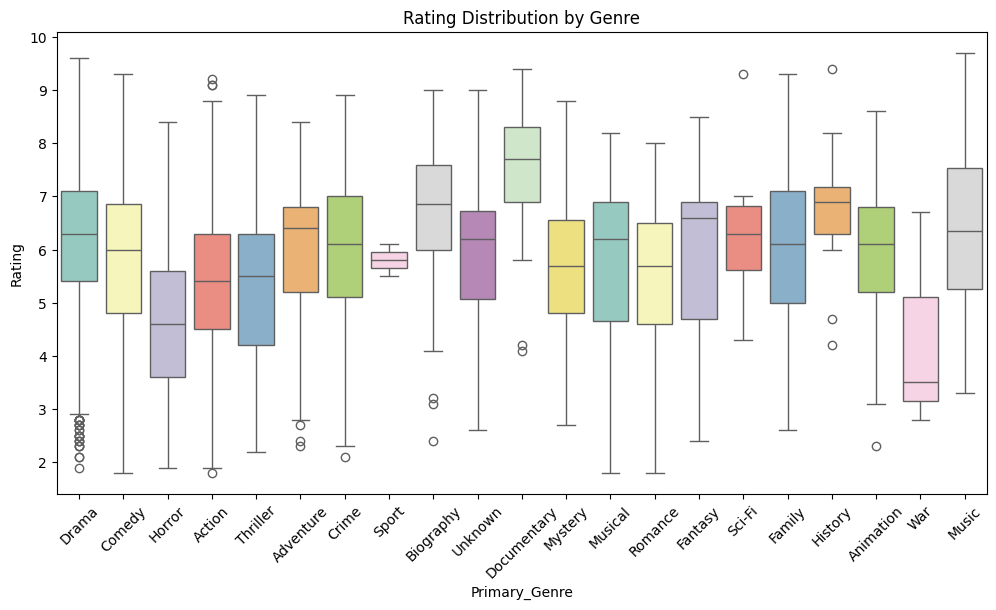

In [252]:
plt.figure(figsize=(12, 6))
# Using Primary_Genre to keep the chart clean
sns.boxplot(data=df, x='Primary_Genre', y='Rating', palette='Set3')
plt.xticks(rotation=45)
plt.title('Rating Distribution by Genre')
plt.show()

### The Power of Popularity (Votes vs. Rating)

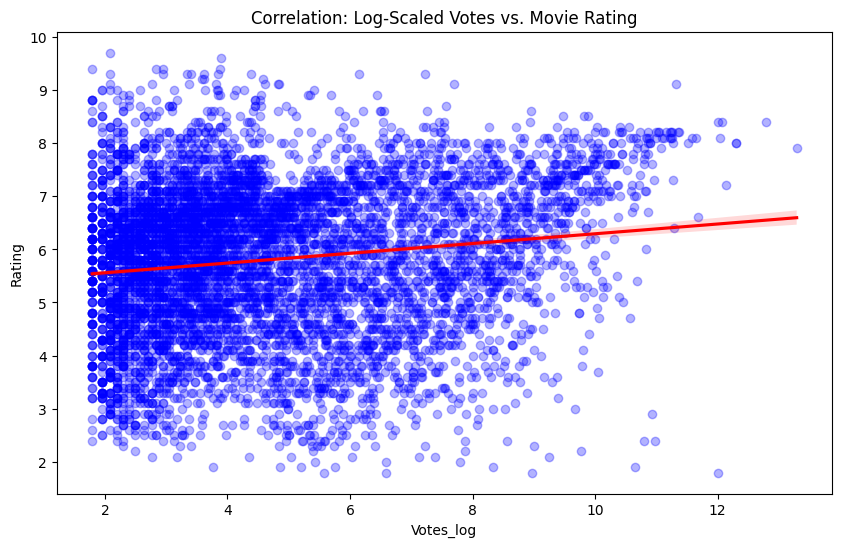

In [253]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Votes_log', y='Rating', 
            scatter_kws={'alpha':0.3, 'color':'blue'}, 
            line_kws={'color':'red'})
plt.title('Correlation: Log-Scaled Votes vs. Movie Rating')
plt.show()

### Rating Trend Over Decades

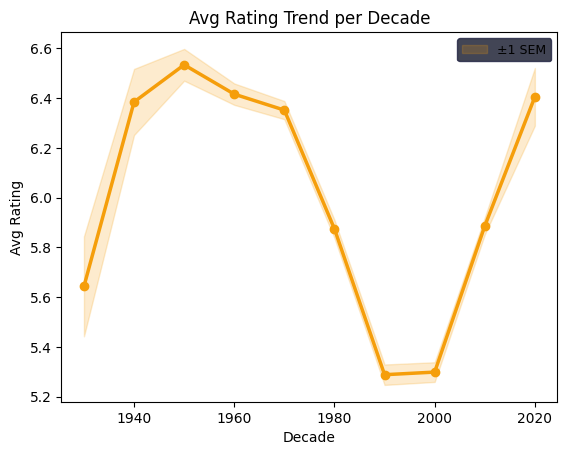

In [254]:
# Calculate average rating per decade with SEM
decade_avg = (df.groupby("Decade")["Rating"]
                .agg(["mean", "sem"]).reset_index())
decade_avg.columns = ["Decade", "Mean", "SEM"]

# Plot mean ratings
plt.plot(decade_avg["Decade"], decade_avg["Mean"],
         color=AMBER, lw=2.5, marker="o", markersize=6)

# Fill ±1 SEM area
plt.fill_between(decade_avg["Decade"],
                 decade_avg["Mean"] - decade_avg["SEM"],
                 decade_avg["Mean"] + decade_avg["SEM"],
                 color=AMBER, alpha=0.2, label="±1 SEM")

# Legend
plt.legend(fontsize=9, facecolor=CARD, edgecolor=BORDER)

# Labels and title
plt.title("Avg Rating Trend per Decade")
plt.xlabel("Decade")
plt.ylabel("Avg Rating")

plt.show()

### Director/Actor Impact (Top Performers)

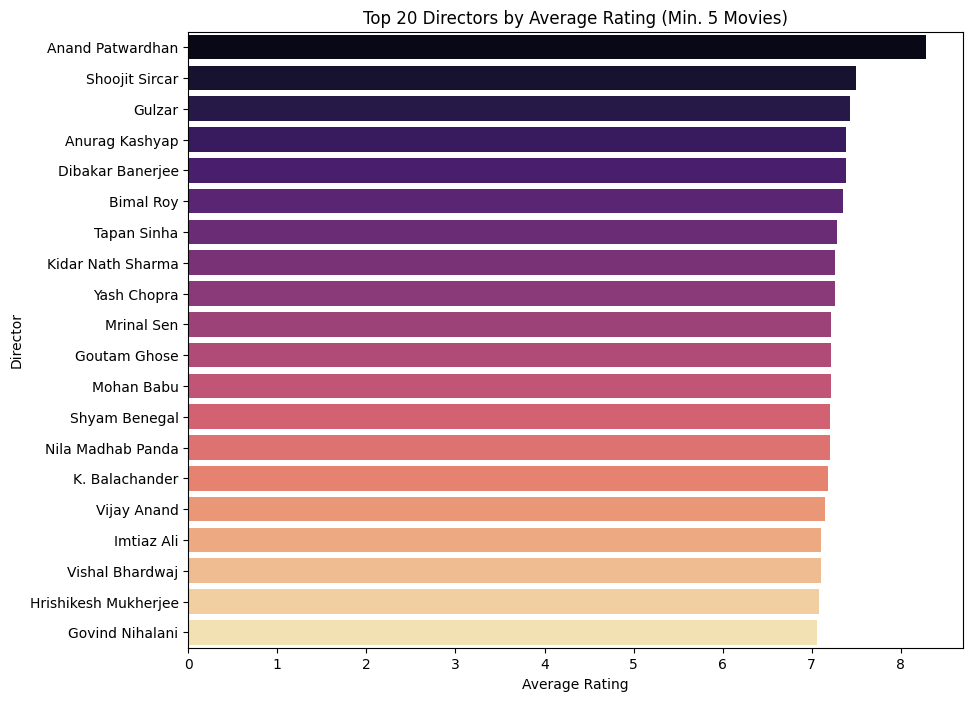

In [255]:
top_directors = df.groupby('Director')['Rating'].agg(['mean', 'count']).query('count > 5')
top_directors = top_directors.sort_values(by='mean', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_directors['mean'], y=top_directors.index, palette='magma')
plt.title('Top 20 Directors by Average Rating (Min. 5 Movies)')
plt.xlabel('Average Rating')
plt.show()

### Feature Correlation Heatmap

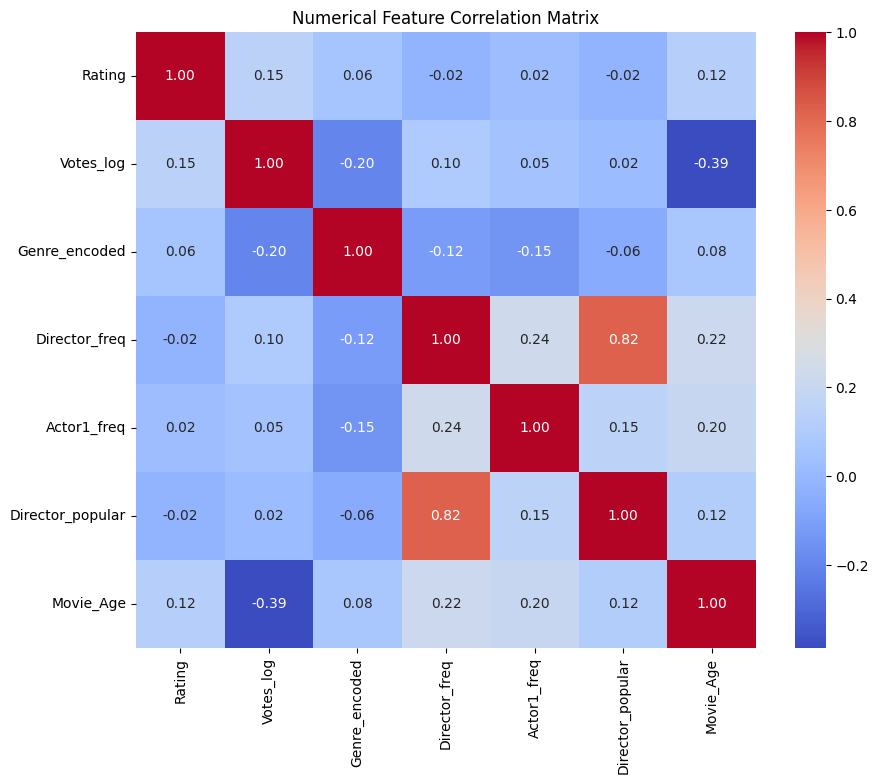

In [256]:
numeric_cols = ['Rating', 'Votes_log', 'Genre_encoded', 'Director_freq', 
                'Actor1_freq', 'Director_popular', 'Movie_Age']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation Matrix')
plt.show()

### EDA Summary

### Genre Leaderboard

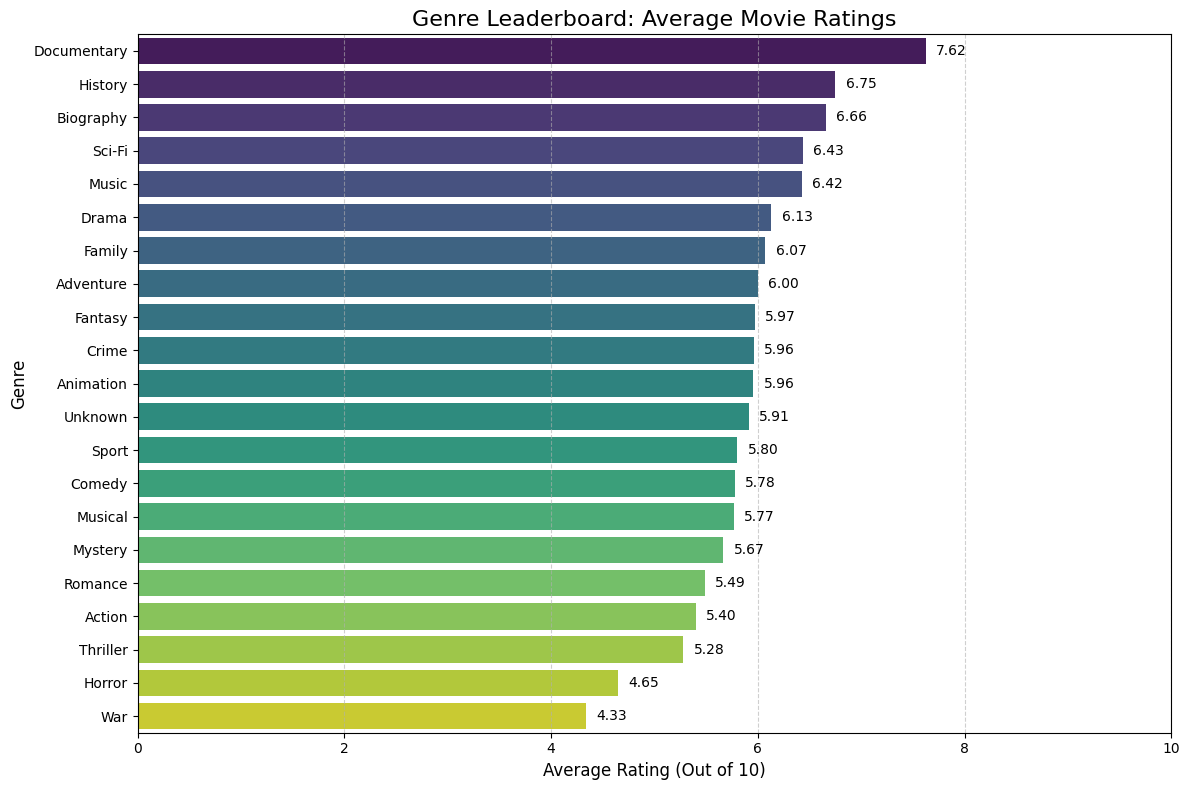

In [257]:
# 1. Calculate average ratings per genre
genre_stats = df.groupby('Primary_Genre')['Rating'].mean().sort_values(ascending=False).reset_index()

# 2. Create the Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(data=genre_stats, x='Rating', y='Primary_Genre', palette='viridis')

# 3. Customizing for a professional look
plt.title('Genre Leaderboard: Average Movie Ratings', fontsize=16)
plt.xlabel('Average Rating (Out of 10)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xlim(0, 10) # Keeps the scale consistent for ratings
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Adding the exact value labels on the bars
for index, value in enumerate(genre_stats['Rating']):
    plt.text(value + 0.1, index, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()

### Star Power Table

In [258]:
def get_star_power(df, column_name, min_movies=5):
    # Group by the person, calculate mean rating and count of movies
    star_stats = df.groupby(column_name)['Rating'].agg(['mean', 'count'])
    
    # Filter by a minimum number of movies to ensure reliability
    star_stats = star_stats[star_stats['count'] >= min_movies]
    
    # Sort by average rating
    return star_stats.sort_values(by='mean', ascending=False).head(10)

# Generate tables for Directors and Lead Actors
top_directors = get_star_power(df, 'Director')
top_actors = get_star_power(df, 'Actor 1')

print("--- Top 10 Directors (Star Power) ---")
print(top_directors)
print("\n--- Top 10 Lead Actors (Star Power) ---")
print(top_actors)

--- Top 10 Directors (Star Power) ---
                          mean  count
Director                             
Anand Patwardhan      8.287500      8
Rajkumar Hirani       8.060000      5
Shoojit Sircar        7.500000      7
Neeraj Pandey         7.460000      5
Gulzar                7.430000     10
Anurag Kashyap        7.385714     14
Dibakar Banerjee      7.383333      6
Nishikant Kamat       7.360000      5
Bimal Roy             7.346154     13
Vikramaditya Motwane  7.320000      5

--- Top 10 Lead Actors (Star Power) ---
                        mean  count
Actor 1                            
Mohan Babu          8.200000      6
N.T. Rama Rao       7.650000      6
Nargis              7.409091     11
Rajkummar Rao       7.300000     10
Sanjay Mishra       7.275000      8
Pankaj Kapur        7.171429      7
Suraiya             7.171429      7
Abhi Bhattacharya   7.160000      5
Irrfan Khan         7.144444     18
Ayushmann Khurrana  7.038462     13


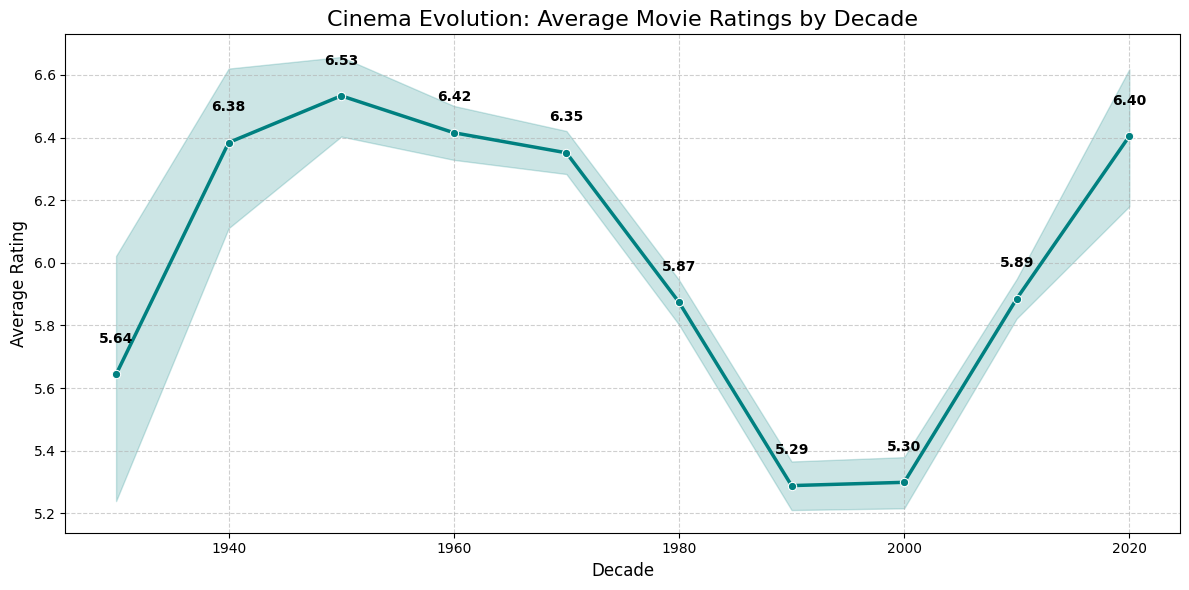

In [259]:
# 1. Prepare the data: Group by Decade and calculate the average Rating
decade_trends = df.groupby('Decade')['Rating'].mean().reset_index()

# 2. Create the Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Decade', y='Rating', marker='o', color='teal', linewidth=2.5)

# 3. Aesthetics for your portfolio
plt.title('Cinema Evolution: Average Movie Ratings by Decade', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Adding data labels for clarity
for x, y in zip(decade_trends['Decade'], decade_trends['Rating']):
    plt.text(x, y + 0.1, f'{y:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Commentary